<a href="https://colab.research.google.com/github/jawaadjariwala/Aramark/blob/main/07_ml_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installs the Python packages needed for this notebook in Google Colab, including BigQuery access, data manipulation, machine learning, and visualization libraries.
!pip install -q google-cloud-bigquery pandas scikit-learn matplotlib seaborn


Installs the Python packages needed for this notebook in Google Colab, including BigQuery access, data manipulation, machine learning, and visualization libraries.

In [2]:
# Authenticates the Colab session with Google Cloud, imports the BigQuery client, and stores the project and dataset identifiers that will be used for queries later in the notebook.
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = "big-data-algorithms-493312"
DATASET_ID = "aramark_spend"
client = bigquery.Client(project=PROJECT_ID)

print("Connected to:", PROJECT_ID)

Connected to: big-data-algorithms-493312


Authenticates the Colab session with Google Cloud, imports the BigQuery client, and stores the project and dataset identifiers that will be used for queries later in the notebook.

In [3]:
# Runs a quick validation query against the raw_spend table to confirm that the connection works and to verify the table size before sampling.
test_sql = f"""
SELECT COUNT(*) AS row_count
FROM `{PROJECT_ID}.{DATASET_ID}.raw_spend`
"""
client.query(test_sql).to_dataframe()
# Expected: ~42,967,459 rows

,row_count
0,42967459


Runs a quick validation query against the raw_spend table to confirm that the connection works and to verify the table size before sampling.

In [4]:
# Uses BigQuery TABLESAMPLE to pull an approximate 1 percent preview of the raw spend table, selecting only the columns needed for segmentation and filtering out known bad rows.
# TABLESAMPLE grabs approximately 1% of the table — ~430K rows.
# Adjust the PERCENT value if you want more or fewer rows.
sql = f"""
SELECT
  year_month,
  business_entity_type,
  customer_market_segment_id,
  state,
  city,
  number_of_rooms,
  distributor_group,
  category_level_1,
  category_level_2,
  spend_random_factor
FROM `{PROJECT_ID}.{DATASET_ID}.raw_spend` TABLESAMPLE SYSTEM (1 PERCENT)
WHERE state NOT IN ('GEORGIA', 'AB')   -- drop the known bad rows
"""
df = client.query(sql).to_dataframe()
print("Sample shape:", df.shape)
df.head()

Sample shape: (220036, 10)


,year_month,business_entity_type,customer_market_segment_id,state,city,number_of_rooms,distributor_group,category_level_1,category_level_2,spend_random_factor
0,202503,GPO,MS-100003,CA,FONTANA,0,MASTER DISTRIBUTOR,FOOD,BAKERY,483.081081
1,202506,GPO,MS-100003,CA,FONTANA,0,MASTER DISTRIBUTOR,FOOD,PRODUCE,103.063063
2,202502,GPO,MS-100003,CA,FONTANA,0,MASTER DISTRIBUTOR,FOOD,MEAT,215.090090
3,202508,GPO,MS-100003,CA,FONTANA,0,MASTER DISTRIBUTOR,FOOD,MEAT,5495.779279
4,202503,GPO,MS-100003,CA,FONTANA,0,MASTER DISTRIBUTOR,BEVERAGE,WATER,156.031532


Uses BigQuery TABLESAMPLE to pull an approximate 1 percent preview of the raw spend table, selecting only the columns needed for segmentation and filtering out known bad rows.

In [5]:
# Draws the main modeling sample with a RAND filter, returning roughly 500K rows into pandas for local preprocessing and clustering.
sql_sample=f"""SELECT * FROM `big-data-algorithms-493312.aramark_spend.raw_spend`
WHERE RAND() < 0.012"""
df_sample = client.query(sql_sample).to_dataframe()
print("Sample shape:", df_sample.shape)


Sample shape: (516090, 23)


Draws the main modeling sample with a RAND filter, returning roughly 500K rows into pandas for local preprocessing and clustering.

In [6]:
# Creates a working copy of the sampled data and fills missing values in the key segmentation fields so the downstream feature engineering and clustering steps do not break on nulls.
import numpy as np
import pandas as pd

seg_df = df_sample.copy()

seg_df["distributor_group"] = seg_df["distributor_group"].fillna("Unknown")
seg_df["category_level_1"] = seg_df["category_level_1"].fillna("Unknown")
seg_df["business_entity_type"] = seg_df["business_entity_type"].fillna("Unknown")
seg_df["number_of_rooms"] = seg_df["number_of_rooms"].fillna(0)

print(seg_df[[
    "distributor_group",
    "category_level_1",
    "business_entity_type",
    "number_of_rooms"
]].isna().sum())

distributor_group       0
category_level_1        0
business_entity_type    0
number_of_rooms         0
dtype: int64


Creates a working copy of the sampled data and fills missing values in the key segmentation fields so the downstream feature engineering and clustering steps do not break on nulls.

In [7]:
# Cleans the spend feature by clipping negative values and then applies a log transform so extreme spend values have less influence during clustering.
seg_df["spend_random_factor"] = seg_df["spend_random_factor"].clip(lower=0)
seg_df["log_spend_random_factor"] = np.log1p(seg_df["spend_random_factor"])

seg_df[["spend_random_factor", "log_spend_random_factor"]].head()


,spend_random_factor,log_spend_random_factor
0,34.382883,3.566228
1,7.500000,2.140066
2,20.873874,3.085293
3,79.175676,4.384220
4,12.644144,2.613310


Cleans the spend feature by clipping negative values and then applies a log transform so extreme spend values have less influence during clustering.

In [8]:
# Summarizes the transformed spend variable to check its distribution and confirm that the log transform behaved as expected.
seg_df["log_spend_random_factor"].describe()


,log_spend_random_factor
count,516090.000000
mean,3.789627
std,1.307033
min,0.000000
25%,2.931074
50%,3.643731
75%,4.543007
max,13.184454


Summarizes the transformed spend variable to check its distribution and confirm that the log transform behaved as expected.

In [9]:
# Converts the raw number_of_rooms field into room size bands so hospitality scale can be represented as a more interpretable categorical feature.
seg_df["room_band"] = pd.cut(
    seg_df["number_of_rooms"],
    bins=[-1, 0, 100, 300, 500, np.inf],
    labels=["0_non_hospitality", "1_100", "101_300", "301_500", "500_plus"]
)

seg_df[["number_of_rooms", "room_band"]].head()


,number_of_rooms,room_band
0,52,1_100
1,56,1_100
2,72,1_100
3,0,0_non_hospitality
4,0,0_non_hospitality


Converts the raw number_of_rooms field into room size bands so hospitality scale can be represented as a more interpretable categorical feature.

In [10]:
# Checks how many records fall into each room band to confirm the binning logic and spot any unexpected category imbalance.
seg_df["room_band"].value_counts(dropna=False)


,count
room_band,
0_non_hospitality,231348
101_300,146303
1_100,95586
301_500,30129
500_plus,12724


Checks how many records fall into each room band to confirm the binning logic and spot any unexpected category imbalance.

In [11]:
# Builds frequency-encoded versions of category_level_1 and distributor_group so common categories and distributor groups can be represented numerically without exploding the feature space.
cat1_freq = seg_df["category_level_1"].value_counts(normalize=True)
dist_freq = seg_df["distributor_group"].value_counts(normalize=True)

seg_df["category_level_1_freq"] = seg_df["category_level_1"].map(cat1_freq)
seg_df["distributor_group_freq"] = seg_df["distributor_group"].map(dist_freq)

seg_df[[
    "category_level_1",
    "category_level_1_freq",
    "distributor_group",
    "distributor_group_freq"
]].head()


,category_level_1,category_level_1_freq,distributor_group,distributor_group_freq
0,DISPOSABLES,0.075938,MASTER DISTRIBUTOR,0.661602
1,FOOD,0.683712,MASTER DISTRIBUTOR,0.661602
2,FOOD,0.683712,MASTER DISTRIBUTOR,0.661602
3,FOOD,0.683712,MASTER DISTRIBUTOR,0.661602
4,FOOD,0.683712,MASTER DISTRIBUTOR,0.661602


Builds frequency-encoded versions of category_level_1 and distributor_group so common categories and distributor groups can be represented numerically without exploding the feature space.

In [12]:
# Verifies that the frequency-encoded columns were created successfully and that no missing values remain after mapping.
seg_df[["category_level_1_freq", "distributor_group_freq"]].isna().sum()


,0
category_level_1_freq,0
distributor_group_freq,0


Verifies that the frequency-encoded columns were created successfully and that no missing values remain after mapping.

In [13]:
# One-hot encodes business_entity_type and room_band so those categorical fields can be used directly by the clustering algorithm.
one_hot_cols = ["business_entity_type", "room_band"]

one_hot_df = pd.get_dummies(
    seg_df[one_hot_cols],
    columns=one_hot_cols,
    drop_first=False
)

print(one_hot_df.shape)
one_hot_df.head()


(516090, 7)


,business_entity_type_GPO,business_entity_type_MANAGED SERVICES,room_band_0_non_hospitality,room_band_1_100,room_band_101_300,room_band_301_500,room_band_500_plus
0,True,False,False,True,False,False,False
1,True,False,False,True,False,False,False
2,True,False,False,True,False,False,False
3,True,False,True,False,False,False,False
4,True,False,True,False,False,False,False


One-hot encodes business_entity_type and room_band so those categorical fields can be used directly by the clustering algorithm.

In [14]:
# Lists the one-hot encoded column names so you can inspect the generated feature set before modeling.
one_hot_df.columns.tolist()


['business_entity_type_GPO',
 'business_entity_type_MANAGED SERVICES',
 'room_band_0_non_hospitality',
 'room_band_1_100',
 'room_band_101_300',
 'room_band_301_500',
 'room_band_500_plus']

Lists the one-hot encoded column names so you can inspect the generated feature set before modeling.

In [15]:
# Combines the numeric base features and the one-hot encoded features into a single modeling matrix X that will be passed into the clustering pipeline.
feature_cols = [
    "log_spend_random_factor",
    "category_level_1_freq",
    "distributor_group_freq"
]

X_base = seg_df[feature_cols].copy()

X = pd.concat([X_base, one_hot_df], axis=1)

print("X shape:", X.shape)
X.head()


X shape: (516090, 10)


,log_spend_random_factor,category_level_1_freq,distributor_group_freq,business_entity_type_GPO,business_entity_type_MANAGED SERVICES,room_band_0_non_hospitality,room_band_1_100,room_band_101_300,room_band_301_500,room_band_500_plus
0,3.566228,0.075938,0.661602,True,False,False,True,False,False,False
1,2.140066,0.683712,0.661602,True,False,False,True,False,False,False
2,3.085293,0.683712,0.661602,True,False,False,True,False,False,False
3,4.384220,0.683712,0.661602,True,False,True,False,False,False,False
4,2.613310,0.683712,0.661602,True,False,True,False,False,False,False


Combines the numeric base features and the one-hot encoded features into a single modeling matrix X that will be passed into the clustering pipeline.

In [16]:
# Checks the data types of the model matrix to confirm that every feature is in a machine-learning-friendly format.
X.dtypes


,0
log_spend_random_factor,float64
category_level_1_freq,float64
distributor_group_freq,float64
business_entity_type_GPO,bool
business_entity_type_MANAGED SERVICES,bool
room_band_0_non_hospitality,bool
room_band_1_100,bool
room_band_101_300,bool
room_band_301_500,bool
room_band_500_plus,bool


Checks the data types of the model matrix to confirm that every feature is in a machine-learning-friendly format.

In [17]:
# Converts boolean dummy columns to integers because sklearn models expect numeric input rather than True/False values.
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

X.dtypes


,0
log_spend_random_factor,float64
category_level_1_freq,float64
distributor_group_freq,float64
business_entity_type_GPO,int64
business_entity_type_MANAGED SERVICES,int64
room_band_0_non_hospitality,int64
room_band_1_100,int64
room_band_101_300,int64
room_band_301_500,int64
room_band_500_plus,int64


Converts boolean dummy columns to integers because sklearn models expect numeric input rather than True/False values.

In [18]:
# Performs a final sanity check on the feature matrix by confirming that there are no missing values and by printing the matrix shape.
X.isna().sum().sum()
X.shape



(516090, 10)

Performs a final sanity check on the feature matrix by confirming that there are no missing values and by printing the matrix shape.

In [19]:
# Repeats the null check to make sure the final modeling data is completely clean before scaling and clustering.
X.isna().sum().sum()


np.int64(0)

Repeats the null check to make sure the final modeling data is completely clean before scaling and clustering.

In [20]:
# Standardizes the feature matrix so variables on different scales contribute more evenly to the distance calculations used by KMeans.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)
X_scaled[:5]


(516090, 10)


array([[-0.17092112, -1.4008529 ,  0.71407931,  0.50290783, -0.50290783,
        -0.90137832,  2.09743215, -0.62900022, -0.24899559, -0.15899003],
       [-1.2620668 ,  0.67932122,  0.71407931,  0.50290783, -0.50290783,
        -0.90137832,  2.09743215, -0.62900022, -0.24899559, -0.15899003],
       [-0.53888099,  0.67932122,  0.71407931,  0.50290783, -0.50290783,
        -0.90137832,  2.09743215, -0.62900022, -0.24899559, -0.15899003],
       [ 0.45491832,  0.67932122,  0.71407931,  0.50290783, -0.50290783,
         1.10941208, -0.47677347, -0.62900022, -0.24899559, -0.15899003],
       [-0.89999122,  0.67932122,  0.71407931,  0.50290783, -0.50290783,
         1.10941208, -0.47677347, -0.62900022, -0.24899559, -0.15899003]])

Standardizes the feature matrix so variables on different scales contribute more evenly to the distance calculations used by KMeans.

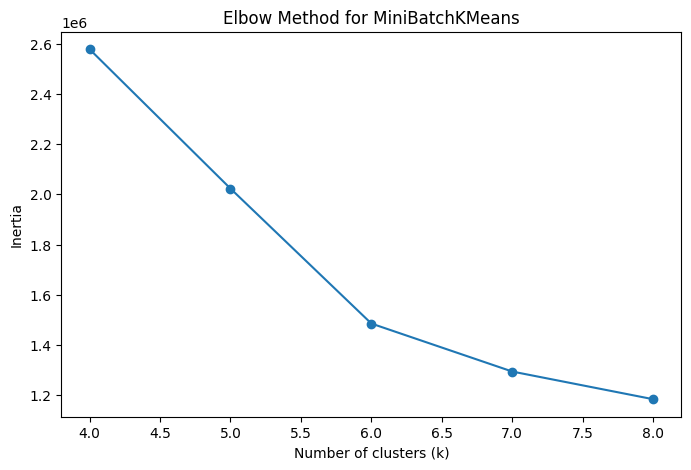

[(4, 2578659.6591605525), (5, 2022999.9850319477), (6, 1484750.3619012104), (7, 1293384.6963979236), (8, 1183072.6140555604)]


In [21]:
# Runs MiniBatchKMeans for several candidate k values, records the inertia for each one, and plots the elbow curve to help choose a reasonable number of clusters.
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt

inertias = []
k_values = range(4, 9)

for k in k_values:
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=10000,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for MiniBatchKMeans")
plt.show()

print(list(zip(k_values, inertias)))


Runs MiniBatchKMeans for several candidate k values, records the inertia for each one, and plots the elbow curve to help choose a reasonable number of clusters.

In [22]:
# Fits the final MiniBatchKMeans model with six clusters and writes the cluster assignments back to the original segmentation DataFrame.
k_final = 6

kmeans = MiniBatchKMeans(
    n_clusters=k_final,
    random_state=42,
    batch_size=10000,
    n_init=10
)

seg_df["cluster"] = kmeans.fit_predict(X_scaled)

seg_df["cluster"].value_counts().sort_index()


,count
cluster,
0,127186
1,104179
2,30129
3,146286
4,95586
5,12724


Fits the final MiniBatchKMeans model with six clusters and writes the cluster assignments back to the original segmentation DataFrame.

In [23]:
# Profiles each cluster by calculating cluster size plus average and median spend, giving a first numeric summary of spending behavior.
cluster_spend = seg_df.groupby("cluster").agg(
    row_count=("cluster", "size"),
    mean_spend=("spend_random_factor", "mean"),
    median_spend=("spend_random_factor", "median"),
    mean_log_spend=("log_spend_random_factor", "mean")
).sort_values("mean_spend", ascending=False)

cluster_spend


,row_count,mean_spend,median_spend,mean_log_spend
cluster,,,,
5,12724,359.558853,71.734234,4.379859
1,104179,243.965726,48.423423,4.088415
2,30129,173.265254,51.531532,4.069991
0,127186,155.228759,35.063063,3.748837
3,146286,92.960682,35.871622,3.702846
4,95586,68.216253,28.864865,3.484128


Profiles each cluster by calculating cluster size plus average and median spend, giving a first numeric summary of spending behavior.

In [24]:
# Finds the most common top-level category in each cluster so the segments can be interpreted by dominant purchasing category.
top_category = (
    seg_df.groupby(["cluster", "category_level_1"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
    .groupby("cluster")
    .head(1)
    .rename(columns={"category_level_1": "top_category"})
)

top_category


,cluster,top_category,count
4,0,FOOD,98315
17,1,FOOD,77968
30,2,FOOD,20059
43,3,FOOD,85860
56,4,FOOD,62086
69,5,FOOD,8569


Finds the most common top-level category in each cluster so the segments can be interpreted by dominant purchasing category.

In [25]:
# Finds the most common distributor group in each cluster to show whether the segments are concentrated around certain supplier relationships.
top_distributor = (
    seg_df.groupby(["cluster", "distributor_group"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
    .groupby("cluster")
    .head(1)
    .rename(columns={"distributor_group": "top_distributor"})
)

top_distributor


,cluster,top_distributor,count
12,0,MASTER DISTRIBUTOR,107215
43,1,MASTER DISTRIBUTOR,69025
74,2,MASTER DISTRIBUTOR,14786
107,3,MASTER DISTRIBUTOR,78949
140,4,MASTER DISTRIBUTOR,65503
172,5,MASTER DISTRIBUTOR,5968


Finds the most common distributor group in each cluster to show whether the segments are concentrated around certain supplier relationships.

In [26]:
# Finds the most common business entity type in each cluster so the segments can be interpreted by organizational context.
top_entity = (
    seg_df.groupby(["cluster", "business_entity_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
    .groupby("cluster")
    .head(1)
    .rename(columns={"business_entity_type": "top_entity_type"})
)

top_entity


,cluster,top_entity_type,count
0,0,GPO,127186
1,1,MANAGED SERVICES,104179
2,2,GPO,30129
3,3,GPO,146286
4,4,GPO,95586
5,5,GPO,12724


Finds the most common business entity type in each cluster so the segments can be interpreted by organizational context.

In [32]:
# Merges the spend summary, dominant category, dominant distributor, and dominant entity type into one cluster profile table.
cluster_profile = cluster_spend.reset_index() \
    .merge(top_category[["cluster", "top_category"]], on="cluster") \
    .merge(top_distributor[["cluster", "top_distributor"]], on="cluster") \
    .merge(top_entity[["cluster", "top_entity_type"]], on="cluster")

cluster_profile


,cluster,row_count,mean_spend,median_spend,mean_log_spend,top_category,top_distributor,top_entity_type
0,5,12724,359.558853,71.734234,4.379859,FOOD,MASTER DISTRIBUTOR,GPO
1,1,104179,243.965726,48.423423,4.088415,FOOD,MASTER DISTRIBUTOR,MANAGED SERVICES
2,2,30129,173.265254,51.531532,4.069991,FOOD,MASTER DISTRIBUTOR,GPO
3,0,127186,155.228759,35.063063,3.748837,FOOD,MASTER DISTRIBUTOR,GPO
4,3,146286,92.960682,35.871622,3.702846,FOOD,MASTER DISTRIBUTOR,GPO
5,4,95586,68.216253,28.864865,3.484128,FOOD,MASTER DISTRIBUTOR,GPO


Merges the spend summary, dominant category, dominant distributor, and dominant entity type into one cluster profile table.

In [28]:
# Finds the most common room band in each cluster to add a simple measure of property size or hospitality scale to the profile.
top_room_band = (
    seg_df.groupby(["cluster", "room_band"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
    .groupby("cluster")
    .head(1)
    .rename(columns={"room_band": "top_room_band"})
)

top_room_band


/tmp/ipykernel_34941/1036057620.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_df.groupby(["cluster", "room_band"])


,cluster,top_room_band,count
0,0,0_non_hospitality,127186
5,1,0_non_hospitality,104162
13,2,301_500,30129
17,3,101_300,146286
21,4,1_100,95586
29,5,500_plus,12724


Finds the most common room band in each cluster to add a simple measure of property size or hospitality scale to the profile.

In [29]:
# Adds the dominant room band information into the cluster profile table, making the summary more business-readable.
cluster_profile = cluster_profile.merge(
    top_room_band[["cluster", "top_room_band"]],
    on="cluster"
)

cluster_profile


,cluster,row_count,mean_spend,median_spend,mean_log_spend,top_category,top_distributor,top_entity_type,top_room_band
0,5,12724,359.558853,71.734234,4.379859,FOOD,MASTER DISTRIBUTOR,GPO,500_plus
1,1,104179,243.965726,48.423423,4.088415,FOOD,MASTER DISTRIBUTOR,MANAGED SERVICES,0_non_hospitality
2,2,30129,173.265254,51.531532,4.069991,FOOD,MASTER DISTRIBUTOR,GPO,301_500
3,0,127186,155.228759,35.063063,3.748837,FOOD,MASTER DISTRIBUTOR,GPO,0_non_hospitality
4,3,146286,92.960682,35.871622,3.702846,FOOD,MASTER DISTRIBUTOR,GPO,101_300
5,4,95586,68.216253,28.864865,3.484128,FOOD,MASTER DISTRIBUTOR,GPO,1_100


Adds the dominant room band information into the cluster profile table, making the summary more business-readable.

In [34]:
cluster_profile.columns.tolist()


['cluster',
 'row_count',
 'mean_spend',
 'median_spend',
 'mean_log_spend',
 'top_category',
 'top_distributor',
 'top_entity_type',
 'cluster_name']

In [35]:
top_room_band = (
    seg_df.groupby(["cluster", "room_band"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
    .groupby("cluster")
    .head(1)
    .rename(columns={"room_band": "top_room_band"})
)

cluster_profile = cluster_profile.merge(
    top_room_band[["cluster", "top_room_band"]],
    on="cluster",
    how="left"
)


/tmp/ipykernel_34941/3186651728.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_df.groupby(["cluster", "room_band"])


In [39]:
# Assigns human-readable business names to the numeric clusters and reorders the columns to create a final presentation-ready segmentation table.
cluster_names = {
    3: "high-spend GPO food buyers",
    1: "high-spend managed services food buyers",
    4: "upper-mid-spend GPO food buyers",
    0: "mid-spend GPO food buyers",
    2: "lower-mid-spend GPO food buyers",
    5: "low-spend GPO food buyers"
}

cluster_profile["cluster_name"] = cluster_profile["cluster"].map(cluster_names)

cluster_profile = cluster_profile[
    [
        "cluster",
        "cluster_name",
        "row_count",
        "mean_spend",
        "median_spend",
        "top_category",
        "top_distributor",
        "top_entity_type",
        "top_room_band",
    ]
]

cluster_profile


,cluster,cluster_name,row_count,mean_spend,median_spend,top_category,top_distributor,top_entity_type,top_room_band
0,5,low-spend GPO food buyers,12724,359.558853,71.734234,FOOD,MASTER DISTRIBUTOR,GPO,500_plus
1,1,high-spend managed services food buyers,104179,243.965726,48.423423,FOOD,MASTER DISTRIBUTOR,MANAGED SERVICES,0_non_hospitality
2,2,lower-mid-spend GPO food buyers,30129,173.265254,51.531532,FOOD,MASTER DISTRIBUTOR,GPO,301_500
3,0,mid-spend GPO food buyers,127186,155.228759,35.063063,FOOD,MASTER DISTRIBUTOR,GPO,0_non_hospitality
4,3,high-spend GPO food buyers,146286,92.960682,35.871622,FOOD,MASTER DISTRIBUTOR,GPO,101_300
5,4,upper-mid-spend GPO food buyers,95586,68.216253,28.864865,FOOD,MASTER DISTRIBUTOR,GPO,1_100


Assigns human-readable business names to the numeric clusters and reorders the columns to create a final presentation-ready segmentation table.

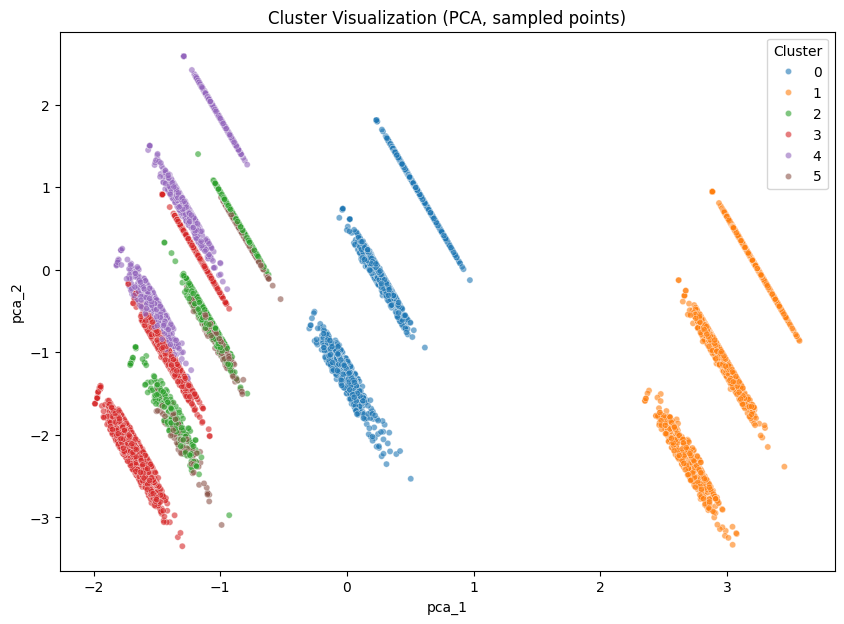

In [38]:
# Uses PCA to reduce the scaled feature space to two dimensions and plots a sampled subset of points so the discovered clusters can be visualized.
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "pca_1": X_pca[:, 0],
    "pca_2": X_pca[:, 1],
    "cluster": seg_df["cluster"].values
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df.sample(20000, random_state=42),  # sample for faster plotting
    x="pca_1",
    y="pca_2",
    hue="cluster",
    palette="tab10",
    alpha=0.6,
    s=20
)
plt.title("Cluster Visualization (PCA, sampled points)")
plt.legend(title="Cluster")
plt.show()


Uses PCA to reduce the scaled feature space to two dimensions and plots a sampled subset of points so the discovered clusters can be visualized.

In [ ]:
# Prints the PCA explained variance ratios so you can judge how much of the original feature variation is captured in the 2D visualization.
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())


Explained variance ratio: [0.28658433 0.15234772]
Total explained variance: 0.4389320526533565


Prints the PCA explained variance ratios so you can judge how much of the original feature variation is captured in the 2D visualization.

## Cluster Interpretation Summary

The clustering analysis produced 6 customer spend segments using spend intensity, category frequency, distributor frequency, business entity type, and room-band features.

### Cluster 3 - High-Spend GPO Food Buyers
- This is the smallest but highest-spend cluster.
- It is dominated by GPO accounts, FOOD purchases, and MASTER DISTRIBUTOR.
- The dominant room profile is `500_plus`, suggesting large hospitality-style operations.
- These customers appear to represent large-scale, high-value food procurement accounts.

### Cluster 1 - High-Spend Managed Services Food Buyers
- This cluster has the second-highest average spend.
- It is dominated by MANAGED SERVICES rather than GPO.
- The dominant room band is `0_non_hospitality`, suggesting institutional or non-hotel operations.
- This segment likely represents high-volume managed-service clients with strong centralized purchasing.

### Cluster 4 - Upper-Mid-Spend GPO Food Buyers
- This group has strong spend levels, but below the top two clusters.
- It is mostly GPO, FOOD, and MASTER DISTRIBUTOR.
- The dominant room band is `301_500`.
- This looks like a medium-to-large hospitality segment with meaningful but not top-tier spend.

### Cluster 0 - Mid-Spend GPO Food Buyers
- This is a large cluster with moderate average spend.
- It is dominated by GPO accounts and non-hospitality room profiles.
- FOOD and MASTER DISTRIBUTOR remain the most common category and distributor.
- This segment likely represents broad mid-market operational buyers.

### Cluster 2 - Lower-Mid-Spend GPO Food Buyers
- This is the largest cluster by row count.
- It has lower average spend than clusters 0, 1, 3, and 4.
- The dominant room band is `101_300`, suggesting medium-sized properties.
- This appears to be a core mid-sized hospitality procurement segment.

### Cluster 5 - Low-Spend GPO Food Buyers
- This is the lowest-spend cluster.
- It is still dominated by GPO, FOOD, and MASTER DISTRIBUTOR.
- The dominant room band is `1_100`, indicating smaller properties.
- This segment likely represents smaller-scale buyers with lighter transaction levels.

## Overall Takeaways
- The strongest segmentation signal is driven by spend intensity, business entity type, and room size.
- Category and distributor are less differentiating because FOOD and MASTER DISTRIBUTOR dominate across nearly all clusters.
- The clusters mainly separate into:
  - managed services vs GPO
  - large vs small property scale
  - high vs low spend intensity
